# Spendy: Customer Loyalty Analysis

Spendy is a Buy Now Pay Later platform and understanding which customers are genuinely loyal to the platform, not just frequent buyers at a single merchant, is key to making smarter marketing decisions.

This notebook builds a data-driven definition of customer loyalty from the ground up, applies it to track how the loyal customer base grows over time, and then trains a model to predict whether a brand new customer will become loyal based on just their first two months of activity.

**Sections:**
1. Data Loading & Exploration
2. Defining a Loyal Customer (component by component)
3. Applying the Loyalty Definition & Tracking Over Time
4. ML Model: Predicting Loyalty from First 2 Months

---
## 1. Data Loading & Exploration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 4)

# In production this would be a BigQuery or S3 read
# e.g. df = bigquery_client.query('SELECT * FROM spendy.transactions').to_dataframe()
df = pd.read_parquet('datascientist_candidate_assignment.parquet')
df['timestamp'] = pd.to_datetime(df['timestamp'])

print('Shape:', df.shape)
print('Date range:', df['timestamp'].min().date(), 'to', df['timestamp'].max().date())
print('Unique users:    ', df['user_id'].nunique())
print('Unique shops:    ', df['shop_id'].nunique())
print('\nCheck for Null values')
print(df.isnull().sum())
df.head()

Shape: (759425, 6)
Date range: 2020-06-01 to 2020-12-31
Unique users:     136830
Unique shops:     711

Check for Null values
purchase_id       0
user_id           0
shop_id           0
timestamp         0
price             0
first_purchase    0
dtype: int64


,purchase_id,user_id,shop_id,timestamp,price,first_purchase
0,pur_53fcfd147ca88240a5ea94b5,user_ec0d4ac3848f69c34f0ab66a,shop_8127ad7a7be187bbe1dcf883,2020-06-20 17:31:25.188,1677.0,False
1,pur_864974906c227708a710637c,user_ec0d4ac3848f69c34f0ab66a,shop_8127ad7a7be187bbe1dcf883,2020-10-05 08:21:49.047,1108.0,False
2,pur_4ec46aa8830377d25fefe638,user_ec0d4ac3848f69c34f0ab66a,shop_8127ad7a7be187bbe1dcf883,2020-12-14 00:43:15.075,4852.0,False
3,pur_1ecf086358a373deec9b2233,user_ec0d4ac3848f69c34f0ab66a,shop_c18cce07bfe84778df2652d5,2020-12-04 15:51:54.062,4306.0,False
4,pur_afce67491f54f4df013e1e94,user_ec0d4ac3848f69c34f0ab66a,shop_8127ad7a7be187bbe1dcf883,2020-10-05 08:19:33.027,1317.0,False


In [2]:
new_users      = df[df['first_purchase'] == True]['user_id'].nunique()
existing_users = df['user_id'].nunique() - new_users

print('New users (joined within dataset window):', new_users)
print('Pre-existing users (joined before dataset):', existing_users)

dataset_end_eda = df['timestamp'].max()

eda_stats = df.groupby('user_id').agg(
    join_date       = ('timestamp', 'min'),
    total_purchases = ('purchase_id', 'count'),
    unique_shops    = ('shop_id', 'nunique')
).reset_index()

eda_stats['months_registered'] = (dataset_end_eda - eda_stats['join_date']).dt.days / 30

New users (joined within dataset window): 72841
Pre-existing users (joined before dataset): 63989


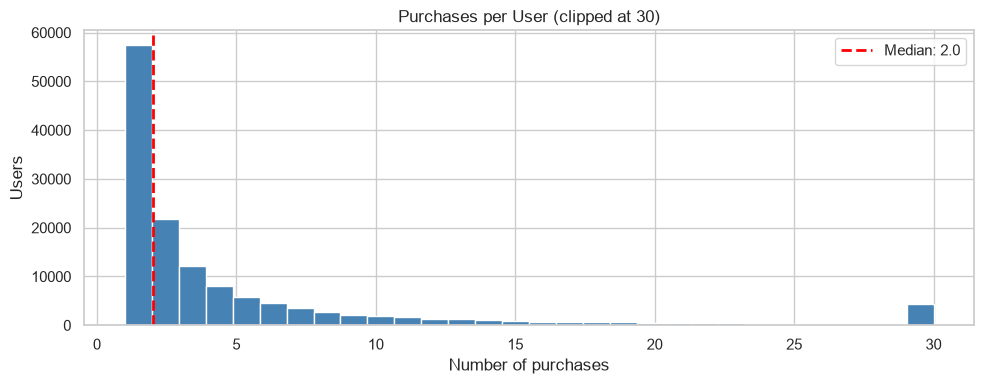

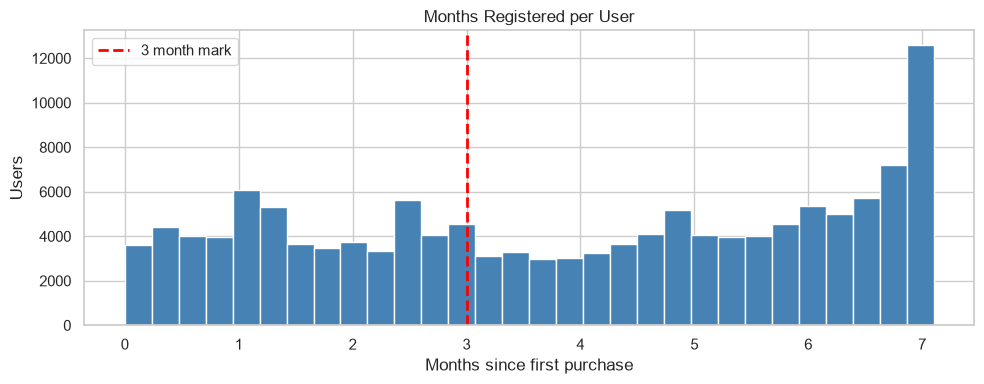

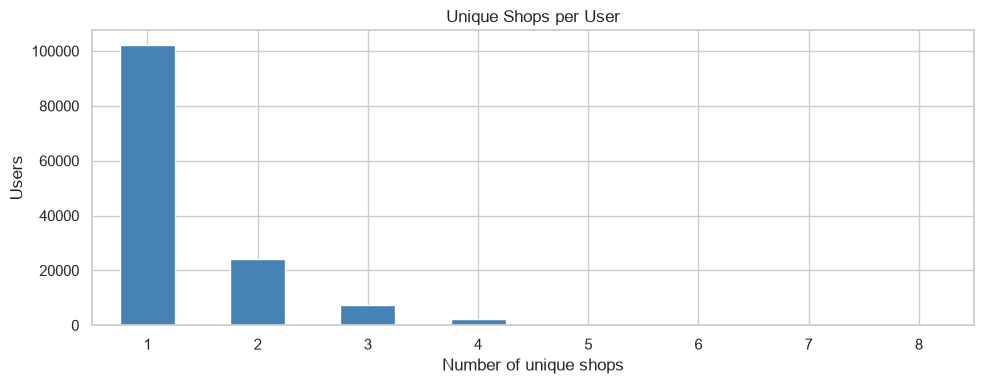

In [3]:
fig, ax = plt.subplots(figsize=(10, 4))
eda_stats['total_purchases'].clip(upper=30).hist(bins=30, ax=ax, color='steelblue', edgecolor='white')
ax.axvline(eda_stats['total_purchases'].median(), color='red', linestyle='--', linewidth=2,
           label='Median: ' + str(eda_stats['total_purchases'].median()))
ax.set_title('Purchases per User (clipped at 30)')
ax.set_xlabel('Number of purchases')
ax.set_ylabel('Users')
ax.legend()
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(10, 4))
eda_stats['months_registered'].hist(bins=30, ax=ax, color='steelblue', edgecolor='white')
ax.axvline(3, color='red', linestyle='--', linewidth=2, label='3 month mark')
ax.set_title('Months Registered per User')
ax.set_xlabel('Months since first purchase')
ax.set_ylabel('Users')
ax.legend()
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(10, 4))
shop_counts = eda_stats['unique_shops'].value_counts().sort_index().head(8)
shop_counts.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Unique Shops per User')
ax.set_xlabel('Number of unique shops')
ax.set_ylabel('Users')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

**Observations:**
- Most users have very few purchases. The distribution is heavily right-skewed with a median of just 2. A simple purchase count is not enough to define loyalty; we need a rate normalised by how long the user has been registered.
- Users are spread fairly evenly across registration tenures (0-7 months), but a large chunk joined recently without enough time to demonstrate loyalty. This motivates a minimum registration requirement before we classify anyone.
- 75% of users have only ever bought from one shop. This is a critical finding: a user buying frequently at one shop may be loyal to that merchant, not to Spendy. Shop diversity must be part of our loyalty definition.

---
## 2. Defining a Loyal Customer

Loyalty here means loyalty to Spendy as a platform, not just being a heavy user of one particular merchant who happens to offer Spendy as a payment option. The goal is to identify customers who have genuinely chosen Spendy across different contexts, spend consistently, and remain active over time.

To get there, five components are defined below, each one grounded in the data. Each component targets a specific dimension of loyalty, and a customer has to satisfy all five to be classified as loyal.

> **Note on pre-existing users:** ~47% of users have no `first_purchase=True` flag, meaning they joined before the dataset window (June 2020). Their true join date is unknown so tenure is measured from June 1, 2020, which slightly understates it and inflates their rates. This is acceptable for the loyalty definition in Section 2 since more data is better. The ML model in Section 4 avoids this entirely by using only new users.

In [4]:
dataset_end = df['timestamp'].max()

user_stats = df.groupby('user_id').agg(
    join_date       = ('timestamp', 'min'),
    last_date       = ('timestamp', 'max'),
    total_purchases = ('purchase_id', 'count'),
    total_spend     = ('price', 'sum'),
    unique_shops    = ('shop_id', 'nunique')
).reset_index()

user_stats['months_registered'] = (dataset_end - user_stats['join_date']).dt.days / 30
user_stats['months_since_last'] = (dataset_end - user_stats['last_date']).dt.days / 30

tenure = user_stats['months_registered'].clip(lower=1)
user_stats['freq_rate']  = user_stats['total_purchases'] / tenure
user_stats['spend_rate'] = user_stats['total_spend'] / tenure

print('User stats built for', len(user_stats), 'users')

User stats built for 136830 users


### 2.1 Purchase Frequency

Frequency is measured as purchases per month rather than a raw count, so that customers with different registration tenures are compared on the same footing. The distribution below is used to find a threshold that separates genuinely regular users from occasional ones.

In [5]:
print('=== Frequency Rate — All Users ===')
print(user_stats['freq_rate'].describe(percentiles=[.25, .5, .75, .90]).round(2))

print('\n% of users above each threshold:')
for t in [0.5, 1.0, 1.5, 2.0, 2.5, 3.0]:
    pct = round((user_stats['freq_rate'] >= t).mean() * 100, 1)
    print('Purchase frequency >=', t, ':', pct, '%')

=== Frequency Rate — All Users ===
count    136830.00
mean          1.39
std           2.25
min           0.14
25%           0.38
50%           0.83
75%           1.46
90%           3.00
max         105.35
Name: freq_rate, dtype: float64

% of users above each threshold:
Purchase frequency >= 0.5 : 66.2 %
Purchase frequency >= 1.0 : 43.8 %
Purchase frequency >= 1.5 : 24.5 %
Purchase frequency >= 2.0 : 18.4 %
Purchase frequency >= 2.5 : 13.2 %
Purchase frequency >= 3.0 : 10.6 %


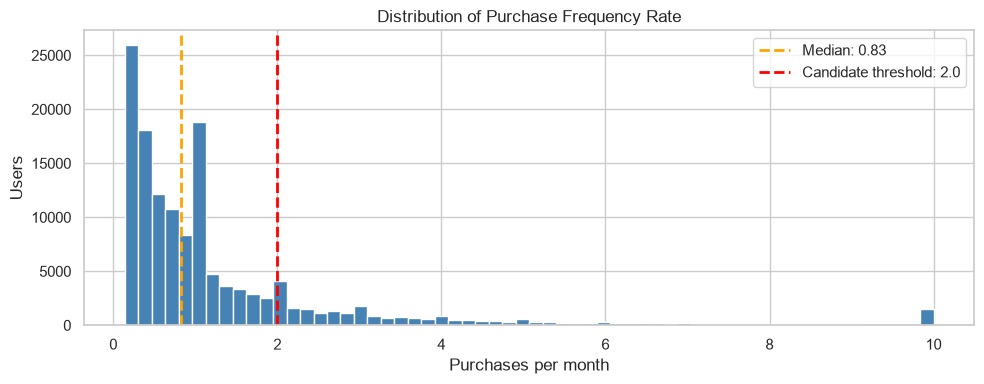

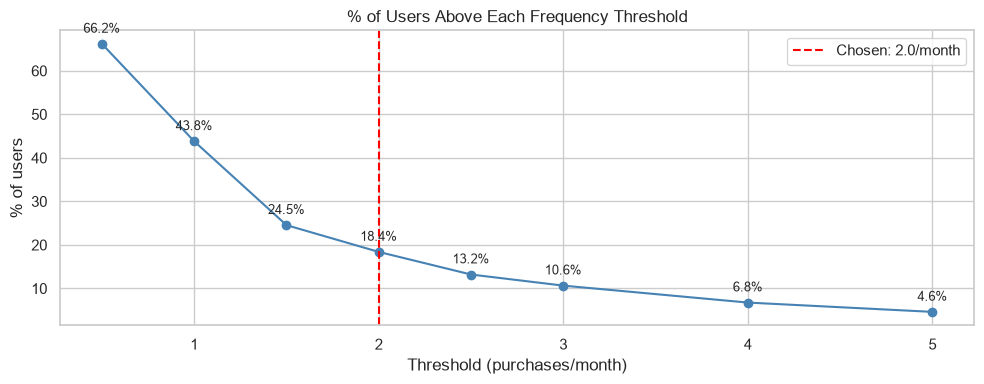

In [6]:
fig1, ax1 = plt.subplots(figsize=(10, 4))
user_stats['freq_rate'].clip(upper=10).hist(bins=60, ax=ax1, color='steelblue', edgecolor='white')
ax1.axvline(user_stats['freq_rate'].median(), color='orange', linestyle='--', linewidth=2,
            label='Median: ' + str(round(user_stats['freq_rate'].median(), 2)))
ax1.axvline(2.0, color='red', linestyle='--', linewidth=2, label='Candidate threshold: 2.0')
ax1.set_title('Distribution of Purchase Frequency Rate')
ax1.set_xlabel('Purchases per month')
ax1.set_ylabel('Users')
ax1.legend()
plt.tight_layout()
plt.show()

thresholds = [0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 4.0, 5.0]
pcts = [(user_stats['freq_rate'] >= t).mean() * 100 for t in thresholds]

fig2, ax2 = plt.subplots(figsize=(10, 4))
ax2.plot(thresholds, pcts, marker='o', color='steelblue')
for x, y in zip(thresholds, pcts):
    ax2.annotate(str(round(y, 1)) + '%', xy=(x, y), xytext=(0, 8), textcoords='offset points', ha='center', fontsize=9)
ax2.axvline(2.0, color='red', linestyle='--', label='Chosen: 2.0/month')
ax2.set_title('% of Users Above Each Frequency Threshold')
ax2.set_xlabel('Threshold (purchases/month)')
ax2.set_ylabel('% of users')
ax2.legend()
plt.tight_layout()
plt.show()

**Finding:** Most users buy less than once a month. The distribution is heavily right-skewed with a natural cluster at 1.0 (once/month users) and a clear elbow in the curve between 1.5 and 2.0.

**Decision: frequency >= 2 purchases/month.**<br> The elbow between 1.5 and 2.0 marks a natural break in the distribution. Below it, users are buying once a month or less, which is more consistent with occasional use than a habit. At 2 purchases per month, there is enough regularity to suggest the customer is actively choosing Spendy rather than just stumbling into it.

In [7]:
min_freq_rate = 2.0

pct = round((user_stats['freq_rate'] >= min_freq_rate).mean() * 100, 1)
print('Users with freq >=', min_freq_rate, 'per month:', pct, '%')

Users with freq >= 2.0 per month: 18.4 %


### 2.2 Monthly Spend

Spend is measured as total spend per month, normalised by tenure for the same reason as frequency. The threshold here is meant to capture customers who are spending at a level that meaningfully contributes to platform revenue, not just making small or incidental transactions.

In [8]:
print('=== Monthly Spend Rate — All Users ===')
print(user_stats['spend_rate'].describe(percentiles=[.25, .5, .75, .90]).round(0))

print('\n% of users above each spend threshold:')
for t in [3000, 5000, 7000, 10000, 15000]:
    pct = round((user_stats['spend_rate'] >= t).mean() * 100, 1)
    print('  >=', t, 'JPY/month:', pct, '%')

=== Monthly Spend Rate — All Users ===
count    136830.0
mean       6006.0
std        9375.0
min           0.0
25%        1261.0
50%        3045.0
75%        6974.0
90%       14011.0
max      235515.0
Name: spend_rate, dtype: float64

% of users above each spend threshold:
  >= 3000 JPY/month: 50.5 %
  >= 5000 JPY/month: 34.4 %
  >= 7000 JPY/month: 24.9 %
  >= 10000 JPY/month: 16.3 %
  >= 15000 JPY/month: 9.0 %


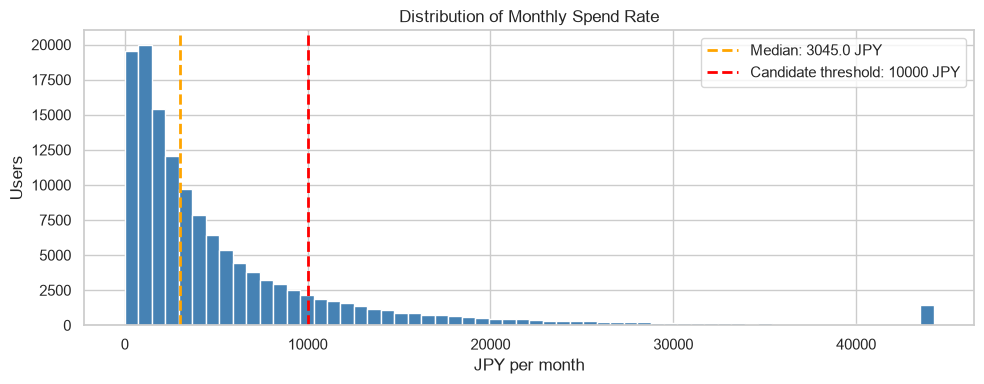

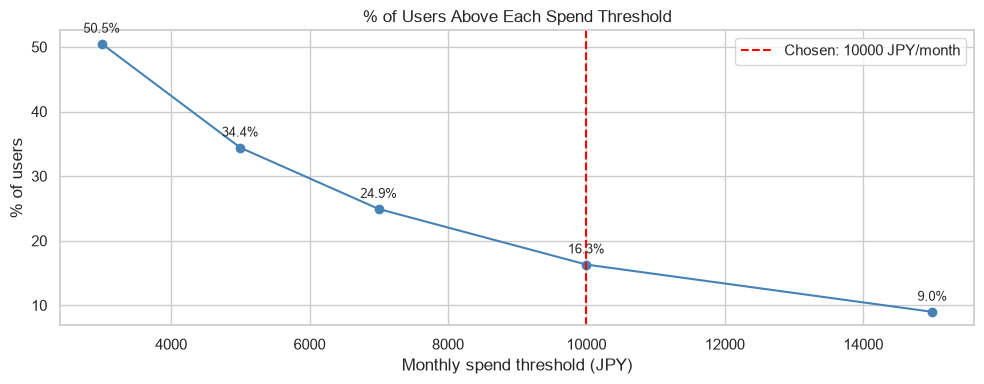

In [9]:
fig1, ax1 = plt.subplots(figsize=(10, 4))
user_stats['spend_rate'].clip(upper=user_stats['spend_rate'].quantile(0.99)).hist(bins=60, ax=ax1, color='steelblue', edgecolor='white')
ax1.axvline(user_stats['spend_rate'].median(), color='orange', linestyle='--', linewidth=2,
            label='Median: ' + str(round(user_stats['spend_rate'].median(), 0)) + ' JPY')
ax1.axvline(10000, color='red', linestyle='--', linewidth=2, label='Candidate threshold: 10000 JPY')
ax1.set_title('Distribution of Monthly Spend Rate')
ax1.set_xlabel('JPY per month')
ax1.set_ylabel('Users')
ax1.legend()
plt.tight_layout()
plt.show()

thresholds_s = [3000, 5000, 7000, 10000, 15000]
pcts_s = [(user_stats['spend_rate'] >= t).mean() * 100 for t in thresholds_s]

fig2, ax2 = plt.subplots(figsize=(10, 4))
ax2.plot(thresholds_s, pcts_s, marker='o', color='steelblue')
for x, y in zip(thresholds_s, pcts_s):
    ax2.annotate(str(round(y, 1)) + '%', xy=(x, y), xytext=(0, 8), textcoords='offset points', ha='center', fontsize=9)
ax2.axvline(10000, color='red', linestyle='--', label='Chosen: 10000 JPY/month')
ax2.set_title('% of Users Above Each Spend Threshold')
ax2.set_xlabel('Monthly spend threshold (JPY)')
ax2.set_ylabel('% of users')
ax2.legend()
plt.tight_layout()
plt.show()

**Finding:** Median monthly spend is around 3,000 JPY and the mean sits around 6,000 JPY. The distribution is heavily right-skewed with most users spending very little per month.

**Decision: Monthly spend >= 10,000 JPY.**<br> The 10,000 JPY mark sits clearly above the mean and captures the top ~16% of users. Below this, spend levels are low enough that they could easily reflect occasional or one-off purchases rather than consistent platform usage. At 10,000 JPY per month, the customer is spending at a level that is actually meaningful to the business.

In [10]:
min_spend_rate = 10000

pct = round((user_stats['spend_rate'] >= min_spend_rate).mean() * 100, 1)
print('Users with spend >=', min_spend_rate, 'JPY/month:', pct, '%')

Users with spend >= 10000 JPY/month: 16.3 %


### 2.3 Shop Diversity

A user who only ever buys from one shop may be loyal to that merchant, not to Spendy as a platform. Shop diversity is the clearest way to separate the two, since a customer using Spendy across multiple merchants is actively choosing the platform, not just accepting it where one particular shop offers it.

In [11]:
print('=== Shop Diversity — All Users ===')
for s in [1, 2, 3, 4]:
    pct = round((user_stats['unique_shops'] >= s).mean() * 100, 1)
    print('  >=', s, 'shop(s):', pct, '% of users')

=== Shop Diversity — All Users ===
  >= 1 shop(s): 100.0 % of users
  >= 2 shop(s): 25.2 % of users
  >= 3 shop(s): 7.6 % of users
  >= 4 shop(s): 2.2 % of users


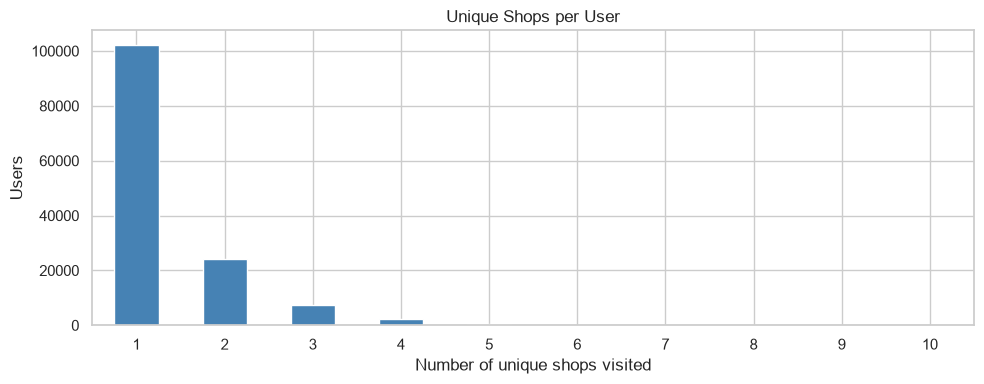

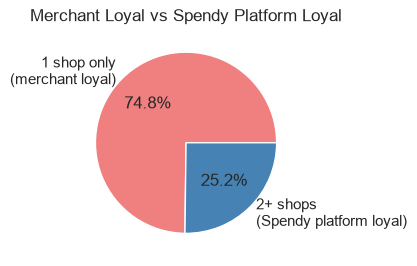

In [12]:
fig1, ax1 = plt.subplots(figsize=(10, 4))
shop_counts = user_stats['unique_shops'].value_counts().sort_index().head(10)
shop_counts.plot(kind='bar', ax=ax1, color='steelblue', edgecolor='white')
ax1.set_title('Unique Shops per User')
ax1.set_xlabel('Number of unique shops visited')
ax1.set_ylabel('Users')
ax1.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

sizes = [
    (user_stats['unique_shops'] == 1).sum(),
    (user_stats['unique_shops'] >= 2).sum()
]
fig2, ax2 = plt.subplots(figsize=(4, 4))
ax2.pie(sizes, labels=['1 shop only\n(merchant loyal)', '2+ shops\n(Spendy platform loyal)'],
        autopct='%1.1f%%', colors=['lightcoral', 'steelblue'])
ax2.set_title('Merchant Loyal vs Spendy Platform Loyal')
plt.tight_layout()
plt.show()

**Finding:** The majority of users only ever buy from one shop. A single-shop user may simply be using Spendy because their favourite merchant happens to offer it, not because they actively chose Spendy as their payment method. Buying at a second shop is the clearest signal that the user is seeking Spendy out, not just accepting it where it is available.

**Decision: Minimum 2 unique shops**<br>  One shop could just be passive acceptance of a merchant's payment options. Two shops means the user deliberately brought Spendy to a new context.

In [13]:
min_unique_shops = 2

pct = round((user_stats['unique_shops'] >= min_unique_shops).mean() * 100, 1)
print('Users with', min_unique_shops, '+ unique shops:', pct, '%')

Users with 2 + unique shops: 25.2 %


### 2.4 Most Recent Purchase

A natural use case for a loyalty definition is that the business rewards loyal customers in terms of cashback, early access, promotions, or similar incentives. If that is the case, the recency component becomes critical: it is not primarily about flagging who is loyal, but about making sure inactive users do not keep receiving those benefits after they have stopped engaging. A user who qualified as loyal six months ago but has since gone quiet should not be treated the same as someone actively using Spendy today.

In [14]:
print('=== Months Since Last Purchase — All Users ===')
print(user_stats['months_since_last'].describe(percentiles=[.25, .5, .75, .90]).round(2))

print('\n% of users with last purchase within X months:')
for t in [1, 2, 3]:
    pct = round((user_stats['months_since_last'] <= t).mean() * 100, 1)
    print('  Within', t, 'month(s):', pct, '%')

=== Months Since Last Purchase — All Users ===
count    136830.00
mean          2.11
std           1.95
min           0.00
25%           0.53
50%           1.37
75%           3.33
90%           5.30
max           7.10
Name: months_since_last, dtype: float64

% of users with last purchase within X months:
  Within 1 month(s): 41.7 %
  Within 2 month(s): 60.3 %
  Within 3 month(s): 72.2 %


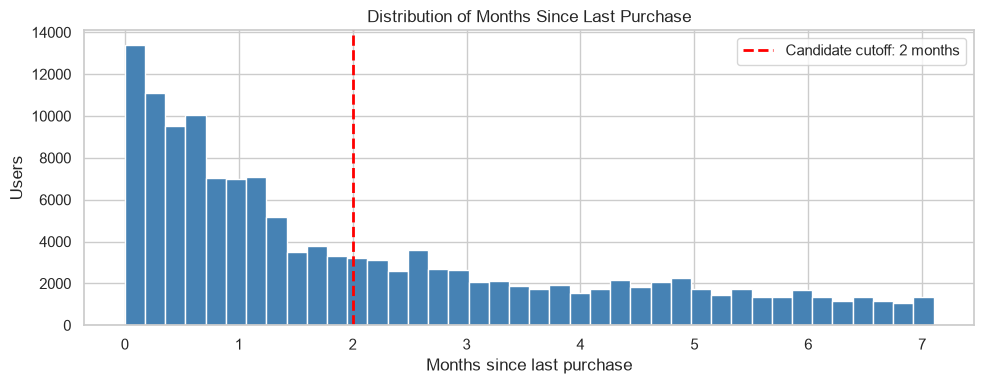

In [15]:
fig, ax = plt.subplots(figsize=(10, 4))
user_stats['months_since_last'].hist(bins=40, ax=ax, color='steelblue', edgecolor='white')
ax.axvline(2, color='red', linestyle='--', linewidth=2, label='Candidate cutoff: 2 months')
ax.set_title('Distribution of Months Since Last Purchase')
ax.set_xlabel('Months since last purchase')
ax.set_ylabel('Users')
ax.legend()
plt.tight_layout()
plt.show()

**Finding:** Most users have purchased recently. A 2-month cutoff gives a reasonable grace period. It does not penalise someone for skipping one month but does flag genuinely inactive users.

**Decision: Last purchase within 2 months.**<br> Strict enough to keep the loyal label meaningful, lenient enough to allow for natural gaps in purchase cycles.

In [16]:
max_months_since_last = 2

pct = round((user_stats['months_since_last'] <= max_months_since_last).mean() * 100, 1)
print('Users with last purchase within', max_months_since_last, 'months:', pct, '%')

Users with last purchase within 2 months: 60.3 %


### 2.5 Minimum Registration Period

This component is justified by **business logic**, not a data threshold. The argument: a user who joins in December during the holiday season can rapidly clear the frequency and spend thresholds through Christmas gift purchases, then never use Spendy again. Without a minimum tenure gate, that user would be classified as loyal based on a single month of seasonal behaviour.

We use the data below only to illustrate the scale of the problem, not to derive the number.

In [17]:
dec_joiners = user_stats[user_stats['join_date'].dt.month == 12].copy()
print('Users who joined in December:', len(dec_joiners))
print('Max months registered for a December joiner:', round(dec_joiners['months_registered'].max(), 2), 'months')

top_dec = dec_joiners.sort_values('freq_rate', ascending=False).head(5)
print('\nTop 5 highest-frequency users who joined in December:')
print(top_dec[['total_purchases', 'months_registered', 'freq_rate', 'spend_rate', 'unique_shops']].to_string(index=False))

dec_joiners['would_be_loyal_no_tenure'] = (
    (dec_joiners['freq_rate']         >= min_freq_rate)    &
    (dec_joiners['spend_rate']        >= min_spend_rate)   &
    (dec_joiners['unique_shops']      >= min_unique_shops) &
    (dec_joiners['months_since_last'] <= max_months_since_last)
)
n_false_loyal = dec_joiners['would_be_loyal_no_tenure'].sum()
print('\nDecember joiners who pass freq + spend + shops + recency (without the tenure gate):', n_false_loyal)
print('These users have at most', round(dec_joiners['months_registered'].max(), 1), 'months of data, not enough to confirm sustained loyalty.')

Users who joined in December: 17594
Max months registered for a December joiner: 1.0 months

Top 5 highest-frequency users who joined in December:
 total_purchases  months_registered  freq_rate  spend_rate  unique_shops
              68           0.366667       68.0     91058.0             1
              35           0.633333       35.0     52569.0             1
              34           0.666667       34.0     24375.0             1
              32           1.000000       32.0     63946.0             1
              30           0.966667       30.0     42200.0             1

December joiners who pass freq + spend + shops + recency (without the tenure gate): 419
These users have at most 1.0 months of data, not enough to confirm sustained loyalty.


**Finding:** December joiners have at most 1 month of data. Users who buy frequently in December are likely doing so for Christmas gift purchases, not as a reflection of sustained platform usage. Without the minimum tenure gate, these users would be incorrectly labelled as loyal.

**Decision: minimum 3 months registered.**<br>
This is a business constraint, not a percentile. Three months gives enough observation window to confirm that a user's behaviour is genuine and not a seasonal spike.

In [18]:
min_months_registered = 3
eligible = user_stats[user_stats['months_registered'] >= min_months_registered]

print('Users with 3+ months registered:', len(eligible), '(', round(len(eligible) * 100.0 / len(user_stats), 1), '% of all users)')
print('Excluded (too new to evaluate):', len(user_stats) - len(eligible))

Users with 3+ months registered: 83007 ( 60.7 % of all users)
Excluded (too new to evaluate): 53823


---
## 3. Applying the Loyalty Definition

We combine all 5 components into one final binary label and track how the loyal customer count evolves month by month using only data available up to that point, simulating how this metric would run in production.

In [19]:
user_stats['is_registered_3m'] = user_stats['months_registered'] >= min_months_registered
user_stats['is_high_freq']     = user_stats['freq_rate']          >= min_freq_rate
user_stats['is_high_spend']    = user_stats['spend_rate']         >= min_spend_rate
user_stats['is_multi_shop']    = user_stats['unique_shops']       >= min_unique_shops
user_stats['is_recent']        = user_stats['months_since_last']  <= max_months_since_last

user_stats['is_loyal'] = (
    user_stats['is_registered_3m'] &
    user_stats['is_high_freq']     &
    user_stats['is_high_spend']    &
    user_stats['is_multi_shop']    &
    user_stats['is_recent']
)

total        = len(user_stats)
loyal_users  = user_stats['is_loyal'].sum()

print('Total users:', total)
print('Loyal customers:', loyal_users, '(', round(loyal_users * 100.0 / total, 1), '% of all users)')

Total users: 136830
Loyal customers: 4559 ( 3.3 % of all users)


In [20]:
months = pd.period_range('2020-06', '2020-12', freq='M')
monthly_loyal = []

for month in months:
    cutoff_date = month.to_timestamp('M')
    transactions_to_date = df[df['timestamp'] <= cutoff_date]
    if transactions_to_date.empty:
        continue

    monthly_stats = transactions_to_date.groupby('user_id').agg(
        join_date       = ('timestamp', 'min'),
        last_date       = ('timestamp', 'max'),
        total_purchases = ('purchase_id', 'count'),
        total_spend     = ('price', 'sum'),
        unique_shops    = ('shop_id', 'nunique')
    ).reset_index()

    monthly_stats['months_registered'] = (cutoff_date - monthly_stats['join_date']).dt.days / 30
    monthly_stats['months_since_last'] = (cutoff_date - monthly_stats['last_date']).dt.days / 30
    tenure = monthly_stats['months_registered'].clip(lower=1)
    monthly_stats['freq_rate']  = monthly_stats['total_purchases'] / tenure
    monthly_stats['spend_rate'] = monthly_stats['total_spend'] / tenure

    monthly_stats['is_loyal'] = (
        (monthly_stats['months_registered'] >= min_months_registered) &
        (monthly_stats['freq_rate']         >= min_freq_rate)         &
        (monthly_stats['spend_rate']        >= min_spend_rate)        &
        (monthly_stats['unique_shops']      >= min_unique_shops)      &
        (monthly_stats['months_since_last'] <= max_months_since_last)
    )

    monthly_loyal.append({
        'month'        : str(month),
        'total_users'  : len(monthly_stats),
        'loyal_users'  : monthly_stats['is_loyal'].sum(),
        'loyalty_rate' : round(monthly_stats['is_loyal'].mean() * 100, 2)
    })

loyalty_over_time = pd.DataFrame(monthly_loyal)
print(loyalty_over_time.to_string(index=False))

  month  total_users  loyal_users  loyalty_rate
2020-06        30549            0          0.00
2020-07        49986            0          0.00
2020-08        67777          486          0.72
2020-09        81048         2577          3.18
2020-10        99585         3222          3.24
2020-11       118493         3805          3.21
2020-12       136455         4540          3.33


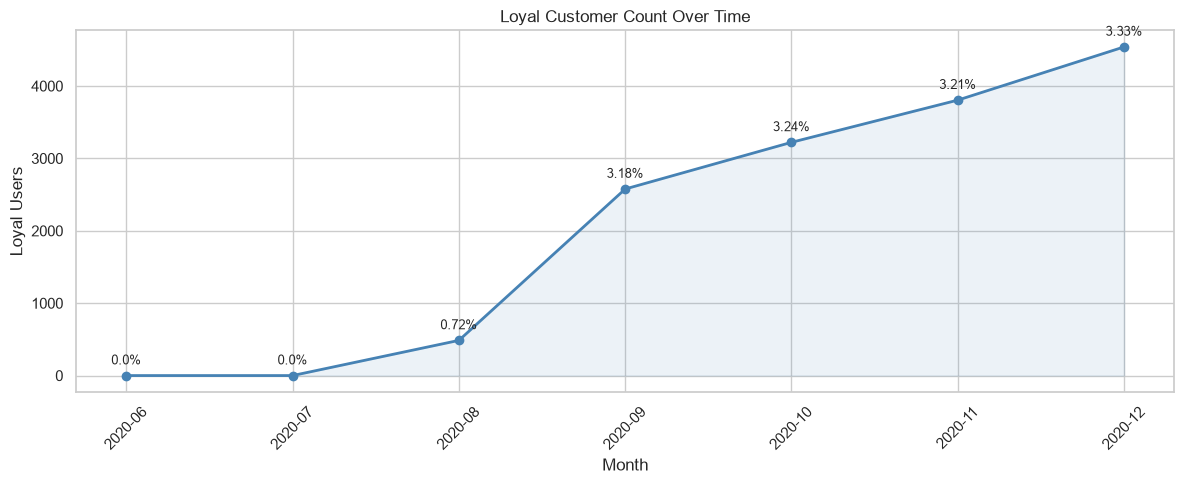

In [21]:
fig, ax = plt.subplots(figsize=(12, 5))

x = range(len(loyalty_over_time))

ax.plot(x, loyalty_over_time['loyal_users'], marker='o', color='steelblue', linewidth=2)
ax.fill_between(x, loyalty_over_time['loyal_users'], alpha=0.1, color='steelblue')
ax.set_xticks(x)
ax.set_xticklabels(loyalty_over_time['month'], rotation=45)
ax.set_xlabel('Month')
ax.set_ylabel('Loyal Users')
ax.set_title('Loyal Customer Count Over Time')

for i, (count, rate) in enumerate(zip(loyalty_over_time['loyal_users'], loyalty_over_time['loyalty_rate'])):
    ax.annotate(str(rate) + '%', xy=(i, count), xytext=(0, 8), textcoords='offset points', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

---
## 4. ML Model: Predicting Loyalty from First 2 Months

If a new customer's loyalty can be predicted early, marketing can act on it before the outcome is already known. Instead of treating all new customers the same, different communication strategies can be applied based on how likely a customer is to become loyal, right after their first two months on the platform.

The model takes only the first 2 months of a new customer's activity as input and predicts whether they will be loyal by Dec 31, evaluated using the same 5-component definition from Section 2. Only new users who joined by Sept 30 are included, so every user in the training set has had at least 3 months in the dataset before the label is assessed.

In [22]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score, ConfusionMatrixDisplay

# Step 1: Identify new users via first_purchase flag, then get ALL their transactions
# first_purchase == True marks only the very first transaction of a new user —
# filtering df to that flag alone would drop all their subsequent purchases
new_user_ids  = df[df['first_purchase'] == True]['user_id'].unique()
new_users_df  = df[df['user_id'].isin(new_user_ids)].copy()
new_user_join = new_users_df.groupby('user_id')['timestamp'].min().rename('join_date').reset_index()

# Step 2: Filter to users with 3+ months in the dataset
# A user who joined after Sept 30 will have less than 3 months by Dec 31 (dataset end)
# and cannot be given a valid loyalty label — they are excluded from training
new_user_join['months_in_dataset'] = (dataset_end - new_user_join['join_date']).dt.days / 30
users_for_model = new_user_join[new_user_join['months_in_dataset'] >= 3].copy()

print('Total new users:', len(new_user_join))
print('Eligible for modelling (3+ months in dataset):', len(users_for_model))
print('Excluded (joined too recently to evaluate):', len(new_user_join) - len(users_for_model))

Total new users: 72841
Eligible for modelling (3+ months in dataset): 34420
Excluded (joined too recently to evaluate): 38421


### 4.1 Feature Construction

We use each user's first 60 days of transactions as the input. This is the only information available at prediction time , after 2 months, marketing wants to act.

The five features map directly to the loyalty components defined in Section 2:

| Feature | Loyalty component |
|---|---|
| `freq_rate_2m` | Purchase frequency |
| `spend_rate_2m` | Monthly spend |
| `unique_shops_2m` | Platform loyalty vs merchant loyalty |
| `days_since_last_purchase_in_window` | Early recency signal — is engagement fading by end of month 2? |
| `spend_month_comparison` | Trend — is spend growing from month 1 to month 2? |

The minimum months registered component is handled at the setup level. It is a data quality gate, not a feature — all users in the training data already satisfy it.

In [23]:
# Pull all transactions for model users and attach their join date
df_model_users = new_users_df[new_users_df['user_id'].isin(users_for_model['user_id'])].copy()
df_model_users = df_model_users.merge(users_for_model[['user_id', 'join_date']], on='user_id')
df_model_users['days_since_join'] = (df_model_users['timestamp'] - df_model_users['join_date']).dt.days

# Keep only transactions within the first 60 days — this is the feature window
df_model_2m = df_model_users[df_model_users['days_since_join'] <= 60].copy()

# Split spend by month for the trend feature (did spending grow from month 1 to month 2?)
model_month1_spend = df_model_2m[df_model_2m['days_since_join'] <= 30].groupby('user_id')['price'].sum().rename('spend_month1')
model_month2_spend = df_model_2m[df_model_2m['days_since_join'] > 30].groupby('user_id')['price'].sum().rename('spend_month2')

# Aggregate one row per user from their first 60 days of transactions
model_features = df_model_2m.groupby('user_id').agg(
    purchases_2m      = ('purchase_id', 'count'),
    total_spend_2m    = ('price', 'sum'),
    unique_shops_2m   = ('shop_id', 'nunique'),
    last_purchase_day = ('days_since_join', 'max'),
).reset_index()

# Attach month-level spend (fillna for users who had no activity in one of the months)
model_features = model_features.merge(model_month1_spend, on='user_id', how='left')
model_features = model_features.merge(model_month2_spend, on='user_id', how='left')
model_features[['spend_month1', 'spend_month2']] = model_features[['spend_month1', 'spend_month2']].fillna(0)

# Derive final features
model_features['freq_rate_2m']  = model_features['purchases_2m'] / 2
model_features['spend_rate_2m'] = model_features['total_spend_2m'] / 2
model_features['days_since_last_purchase_in_window'] = 60 - model_features['last_purchase_day']
model_features['spend_month_comparison'] = model_features['spend_month2'] / (model_features['spend_month1'] + 1)

print('Feature matrix:', model_features.shape)
model_features[['freq_rate_2m', 'spend_rate_2m', 'unique_shops_2m',
                'days_since_last_purchase_in_window', 'spend_month_comparison']].describe().round(2)

Feature matrix: (34420, 11)


,freq_rate_2m,spend_rate_2m,unique_shops_2m,days_since_last_purchase_in_window,spend_month_comparison
count,34420.00,34420.00,34420.00,34420.00,34420.00
mean,1.24,5028.62,1.12,46.81,0.36
std,1.95,6948.26,0.37,20.83,1.60
min,0.50,0.50,1.00,0.00,0.00
25%,0.50,1505.00,1.00,31.00,0.00
50%,0.50,2884.00,1.00,60.00,0.00
75%,1.00,5750.50,1.00,60.00,0.00
max,65.50,262844.00,6.00,60.00,76.24


### 4.2 Label Construction

We evaluate loyalty at the **dataset end date (Dec 31)** for each eligible user. This gives users the maximum observation window available in the data, producing a realistic loyalty rate to train on. Users who joined June–Sept have between 3 and 7 months of history by Dec 31 — enough time to genuinely demonstrate loyal behaviour across all 5 components.

The `is_loyal` label is taken directly from `user_stats` computed in Section 2, filtered to eligible new users only. No recomputation needed.

In [24]:
# Reuse is_loyal from user_stats (Section 2) — already computed at Dec 31 for all users
# Filter to users_for_model only
labels = user_stats[user_stats['user_id'].isin(users_for_model['user_id'])][['user_id', 'is_loyal']]

print('Label distribution:')
print(labels['is_loyal'].value_counts())
print('Loyalty rate:', round(labels['is_loyal'].mean() * 100, 1), '%')

Label distribution:
is_loyal
False    33547
True       873
Name: count, dtype: int64
Loyalty rate: 2.5 %


In [25]:
model_data = model_features.merge(labels, on='user_id', how='inner')

feature_cols = ['freq_rate_2m', 'spend_rate_2m', 'unique_shops_2m',
                'days_since_last_purchase_in_window', 'spend_month_comparison']

X = model_data[feature_cols]
y = model_data['is_loyal']

print('Model dataset:', len(model_data), 'users')
print('Loyal:    ', y.sum(), '(', round(y.mean() * 100, 1), '%)')
print('Not loyal:', (~y).sum(), '(', round((~y).mean() * 100, 1), '%)')

Model dataset: 34420 users
Loyal:     873 ( 2.5 %)
Not loyal: 33547 ( 97.5 %)


### 4.3 Model Training

The model choice here is Random Forest, and the reasoning ties directly back to how the problem is set up.

The loyalty definition is built on hard thresholds, a user either crosses 2 purchases/month or they don't, either hits 10,000 JPY or they don't. That means the relationship between the features and the label is non-linear by design. Random Forest handles this naturally since it learns through decision tree splits, which essentially mirror the same threshold logic. A linear model like Logistic Regression would struggle here because it assumes a smooth relationship between features and the outcome, which isn't really the case.

The features also have a scale problem, `spend_rate_2m` can go up to ~50,000 JPY while `freq_rate_2m` sits between 0 and 10. On top of that, `spend_rate_2m` and `spend_month_comparison` are both derived from spend so they're correlated. These are exactly the kinds of issues that hurt Logistic Regression, and Random Forest doesn't care about either.

Probabilities are needed as the output, not just a class label, since the goal is to rank and segment customers. Random Forest's `predict_proba` works well for this, and the feature importances it gives are a bonus as they make it easy to explain what the model is actually picking up on.

`class_weight='balanced'` accounts for the class imbalance since most users are not loyal, and a stratified 80/20 split ensures the loyal-to-non-loyal ratio is preserved in both train and test sets.

In [26]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf_model.fit(X_train, y_train)
y_pred  = rf_model.predict(X_test)
y_proba = rf_model.predict_proba(X_test)[:, 1]

print('Train size:', len(X_train), '| Test size:', len(X_test))

Train size: 27536 | Test size: 6884


### 4.4 Model Evaluation

ROC-AUC measures how well the model separates loyal from non-loyal users across all probability thresholds. For the classification report, the key metric to focus on is recall for the loyal class, missing a future loyal customer means a missed opportunity, which is more costly to the business than a false positive.

ROC-AUC: 0.878

              precision    recall  f1-score   support

   Not Loyal       0.99      0.98      0.98      6709
       Loyal       0.36      0.46      0.40       175

    accuracy                           0.97      6884
   macro avg       0.67      0.72      0.69      6884
weighted avg       0.97      0.97      0.97      6884



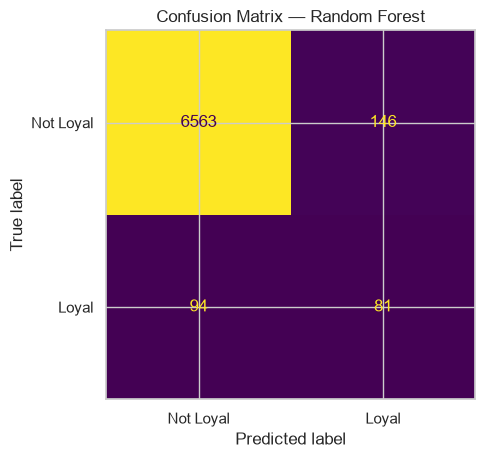

In [27]:
print('ROC-AUC:', round(roc_auc_score(y_test, y_proba), 3))
print()
print(classification_report(y_test, y_pred, target_names=['Not Loyal', 'Loyal']))

fig, axis = plt.subplots(figsize=(5, 5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=['Not Loyal', 'Loyal'],
                                        ax=axis, colorbar=False)
axis.set_title('Confusion Matrix — Random Forest')
plt.tight_layout()
plt.show()

The class imbalance is the main factor shaping these results. Only 2.5% of users are loyal, so the model has very few positive examples to learn from. This is why precision on the loyal class is low at 0.36, the model flags more users as likely loyal than actually turn out to be. `class_weight='balanced'` helps by giving the loyal class more weight during training, which improves recall to 0.46 at the cost of some precision. For this use case that is a reasonable trade-off since missing a genuinely loyal customer is more costly than occasionally acting on a false positive.

The ROC-AUC came in at 0.878, which is a strong result. With 97.5% of users being non-loyal, accuracy is a useless metric here since a model that simply predicts everyone as not loyal would score 97.5% while being completely useless. The ROC-AUC of 0.878 means the model correctly ranks a loyal user above a non-loyal one 87.8% of the time, which is what actually matters for segmentation.

Feature importance shows which signals the model relies on most. If the model is working correctly, `spend_rate_2m` and `freq_rate_2m` should rank near the top since they are the two most directly tied to the loyalty definition. An unexpected feature dominating would be a red flag for data leakage or a poorly specified feature.

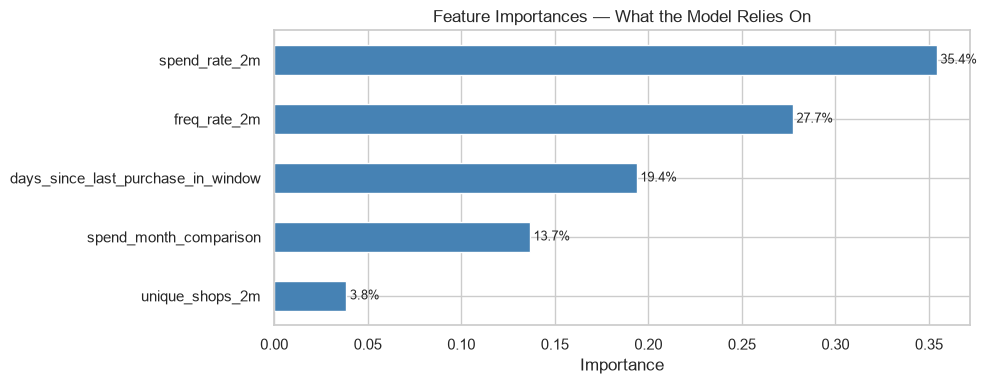

In [28]:
importance = pd.Series(rf_model.feature_importances_, index=feature_cols).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 4))
importance.plot(kind='barh', ax=ax, color='steelblue')
for i, val in enumerate(importance.values):
    ax.text(val + 0.002, i, str(round(val * 100, 1)) + '%', va='center', fontsize=9)
ax.set_title('Feature Importances — What the Model Relies On')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

### 4.5 Segmentation — Business Output

The model's primary deliverable is a probability score for each new customer after their first 2 months. Customers are bucketed into three segments, each calling for a different marketing response.

| Segment | Suggested approach |
|---|---|
| **High likelihood** | Reinforce: reward early signals with exclusive offers or early access to build on existing momentum |
| **Medium likelihood** | Nudge: targeted campaigns to close the gap: spend incentives, merchant discovery prompts |
| **Low likelihood** | Re-engage or deprioritise: investigate whether there is a re-engagement trigger, or redirect budget to higher-value segments |

The model is applied to all eligible new users, not just the test set, to generate a loyalty probability score for each one. These scores are then bucketed into three segments based on where they fall between 0 and 1. Users below 0.33 go into Low likelihood, between 0.33 and 0.66 into Medium, and above 0.66 into High.

The summary table shows how many users land in each segment, how many of them actually turned out to be loyal, and what the average predicted probability looks like per segment. This is a sanity check on whether the model's confidence is tracking reality. The bar chart gives a quick visual of how the user base distributes across segments, which is the view marketing would actually use to decide where to focus effort.

                   users  actual_loyal  avg_prob
segment                                         
Low likelihood      6905            57     0.090
Medium likelihood    825            41     0.464
High likelihood      910           753     0.954


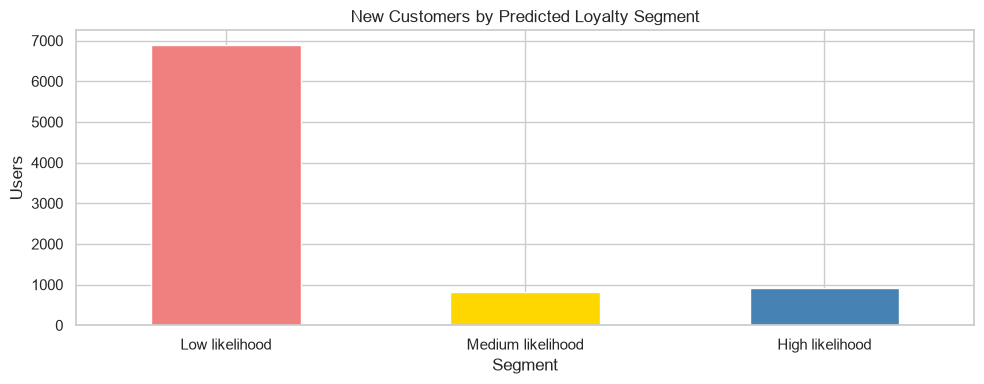

In [29]:
# Score all eligible new users (not just test set) with their loyalty probability
all_proba = rf_model.predict_proba(X)[:, 1]  # [:, 1] picks the probability of being loyal

# Create a fresh output dataframe so model_data stays clean across retrains
scored_data = model_data.copy()
scored_data['loyalty_prob'] = all_proba

# Bucket scores into three segments based on probability thresholds
scored_data['segment'] = pd.cut(
    scored_data['loyalty_prob'],
    bins=[0, 0.33, 0.66, 1.0],
    labels=['Low likelihood', 'Medium likelihood', 'High likelihood']
)

# Summary: how many users per segment, how many were actually loyal, average predicted probability
seg_summary = scored_data.groupby('segment', observed=True).agg(
    users        = ('user_id', 'count'),
    actual_loyal = ('is_loyal', 'sum'),
    avg_prob     = ('loyalty_prob', 'mean')
).round(3)
print(seg_summary.to_string())

# Bar chart of user count per segment
fig, ax = plt.subplots(figsize=(10, 4))
scored_data['segment'].value_counts().sort_index().plot(kind='bar', ax=ax,
    color=['lightcoral', 'gold', 'steelblue'], edgecolor='white')
ax.set_title('New Customers by Predicted Loyalty Segment')
ax.set_xlabel('Segment')
ax.set_ylabel('Users')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

The majority of users land in Low likelihood with 6,905 users and an actual loyalty rate of just 0.8%, which makes sense given the overall base rate of 2.5%. The High likelihood segment has 910 users and an actual loyalty rate of 82.7%, meaning more than 4 in 5 users the model was confident about actually turned out to be loyal. Medium sits at 5.0%, noticeably above Low but far from High.

The average predicted probabilities back this up. Low averages 0.09, Medium 0.46, and High 0.95. The model is not hedging, it is producing confident scores at both ends, which is what makes the segmentation actionable. Marketing does not need to worry about users in the borderline range dominating the output.